# Potential problems in linear regression

The point of this document is to explore common problems that may arise when fitting a linear regression model and use generative AI to create examples that illustrate these issues.

### Non-linearity of the response-predictor relationships

The linear regression model assumes a straight-line relationship between the predictors and the response. As we know, not all relationships between variables are linear. This matters because if the relationship between the variables is curved, then conclusions that we draw from the fit are suspect, and the prediction accuracy of the model can be significantly reduced. A residual plot can be used to identify non-linearity. If it is a simple model, we can plot the residuals, ei = yi − ŷi, versus the predictor xi, and if it is a multiple regression model, we can instead plot the residuals versus the predicted (or fitted) values ŷi. Ideally, the residual plot will show no discernible pattern. To fix this, we can apply transformations on predictors like log X, √X, or X².

Question: A question I have is how to know when something is truly a simple model with just one predictor and one response variable? I am now scared to assume such a thing because of how much I have been learning about other confounders.

Answer: After investigating this question, I learned that it is always good to check if removing or adding a variable meaningfully changes your coefficients. 

### Non-constant variance of error terms

Another important assumption of the linear regression model is that the error terms have a constant variance, Var("i) = σ2. This matters because “the standard errors, confidence intervals, and hypothesis tests associated with the linear model rely upon this assumption”. Unfortunately, the variances of the error terms are often non-constant, so it is important to have ways to detect & address them. A great way to detect this is by using a residual plot and looking for a funnel shape. This can be addressed by transforming the response with a concave function like log Y or √Y. It can also be addressed by using weighted least squares.

Question: After reading this, I’m still a little confused about how a residual plot actually forms a funnel shape when the error terms don’t have a constant variance, Var("i) = σ2. 

Answer: After doing more investigating, I learned that the funnel shape forms because the bigger the fitted value, the more the residuals spread out.


### High-leverage points

High-leverage points have very unusual predictor values. These predictor values tend to sit far from the bulk of the data in the predictor space. This can cause problems because these values distort the regression line. In fact, removing these points has a much more substantial impact on the least squares line than removing the outlier. Due to their effects on regression lines, it's important to identify them in your model. In a simple model, they can be spotted visually, but in a multiple regression model, leverage statistics are needed. These can be dealt with by deleting them, but these points should be investigated beforehand because they may reveal a real pattern.


Question: I honestly don’t know how I would discern these from a regular outlier in my models.

Answer: After doing more investigation, I learned that an outlier is a weird value in the response, and a high-leverage point is a weird predictor in the predictor.


To generate the code below, I used CLAUDE.AI. The prompt I gave it was:

```
High-Leverage Points
Non-constant Variance of Error Terms
Non-linearity of the Response-Predictor Relationship

For each of the three issues, use a generative AI tool (such as ChatGPT, Claude, or Claude code) to write Python code that:
generates synthetic data that clearly illustrates the issue
produces plots, making the issue visually clear
```

The only mistake that CLAUDE made was that it tried saving the plots it made as PNGs to a folder that doesn’t exist instead of just printing them. This was an easy fix, though, plus I didn’t give it too much context on how I wanted it done. This whole thing only took 1 try. The way I identified the issue was that I got an error saying the file it wanted to save the PNGs to didn’t exist. I am honestly kind of surprised by how good a job it did.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)
n = 100

# ─────────────────────────────────────────────
# 1. NON-LINEARITY
# ─────────────────────────────────────────────
x1 = np.linspace(0, 10, n)
y1 = 2 * x1**2 - 5 * x1 + np.random.normal(0, 5, n)  # true relationship is quadratic

lin_model = LinearRegression().fit(x1.reshape(-1, 1), y1)
y1_pred_lin = lin_model.predict(x1.reshape(-1, 1))
resid_lin = y1 - y1_pred_lin

poly = PolynomialFeatures(degree=2)
x1_poly = poly.fit_transform(x1.reshape(-1, 1))
quad_model = LinearRegression().fit(x1_poly, y1)
y1_pred_quad = quad_model.predict(x1_poly)
resid_quad = y1 - y1_pred_quad

fig1, axes = plt.subplots(1, 3, figsize=(15, 4))
fig1.suptitle("1. Non-linearity of the Response-Predictor Relationship", fontsize=13, fontweight="bold")

axes[0].scatter(x1, y1, alpha=0.6, color="steelblue")
axes[0].plot(x1, y1_pred_lin, color="red", label="Linear fit")
axes[0].set_title("Data with Linear Fit")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")
axes[0].legend()

axes[1].scatter(y1_pred_lin, resid_lin, alpha=0.6, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals – Linear Fit (U-shape = problem)")
axes[1].set_xlabel("Fitted Values"); axes[1].set_ylabel("Residuals")

axes[2].scatter(y1_pred_quad, resid_quad, alpha=0.6, color="steelblue")
axes[2].axhline(0, color="green", linestyle="--")
axes[2].set_title("Residuals – Quadratic Fit (Fixed)")
axes[2].set_xlabel("Fitted Values"); axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.close()

# ─────────────────────────────────────────────
# 2. HETEROSCEDASTICITY (Non-constant variance)
# ─────────────────────────────────────────────
x2 = np.linspace(1, 10, n)
y2 = 3 * x2 + np.random.normal(0, x2 * 1.2, n)   # variance grows with x

model2 = LinearRegression().fit(x2.reshape(-1, 1), y2)
y2_pred = model2.predict(x2.reshape(-1, 1))
resid2 = y2 - y2_pred

# Fix: log-transform Y
y2_log = np.log(y2 - y2.min() + 1)
model2_log = LinearRegression().fit(x2.reshape(-1, 1), y2_log)
y2_log_pred = model2_log.predict(x2.reshape(-1, 1))
resid2_log = y2_log - y2_log_pred

fig2, axes = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle("2. Non-constant Variance of Error Terms (Heteroscedasticity)", fontsize=13, fontweight="bold")

axes[0].scatter(x2, y2, alpha=0.6, color="darkorange")
axes[0].plot(x2, y2_pred, color="red")
axes[0].set_title("Data with Linear Fit")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")

axes[1].scatter(y2_pred, resid2, alpha=0.6, color="darkorange")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals – Raw Y (Funnel = problem)")
axes[1].set_xlabel("Fitted Values"); axes[1].set_ylabel("Residuals")

axes[2].scatter(y2_log_pred, resid2_log, alpha=0.6, color="darkorange")
axes[2].axhline(0, color="green", linestyle="--")
axes[2].set_title("Residuals – log(Y) Transform (Fixed)")
axes[2].set_xlabel("Fitted Values"); axes[2].set_ylabel("Residuals")


plt.tight_layout()
plt.close()

# ─────────────────────────────────────────────
# 3. HIGH-LEVERAGE POINTS
# ─────────────────────────────────────────────
x3 = np.random.normal(5, 1, n)
y3 = 2 * x3 + np.random.normal(0, 1, n)

# Add one high-leverage point far out on X
x3_lev = np.append(x3, 20)
y3_lev = np.append(y3, 2 * 20 + np.random.normal(0, 1))   # on the true line
x3_lev_bad = np.append(x3, 20)
y3_lev_bad = np.append(y3, 5)                              # off the true line — influential

model3_clean = LinearRegression().fit(x3.reshape(-1, 1), y3)
model3_good  = LinearRegression().fit(x3_lev.reshape(-1, 1), y3_lev)
model3_bad   = LinearRegression().fit(x3_lev_bad.reshape(-1, 1), y3_lev_bad)

x_line = np.linspace(4, 21, 200)

fig3, axes = plt.subplots(1, 2, figsize=(12, 4))
fig3.suptitle("3. High-Leverage Points", fontsize=13, fontweight="bold")

# Left: high-leverage point that DOES distort the line
axes[0].scatter(x3, y3, alpha=0.5, color="steelblue", label="Normal data")
axes[0].scatter(20, 5, color="red", s=100, zorder=5, label="High-leverage (influential)")
axes[0].plot(x_line, model3_clean.predict(x_line.reshape(-1,1)), color="blue", linestyle="--", label="Fit without point")
axes[0].plot(x_line, model3_bad.predict(x_line.reshape(-1,1)),   color="red",  label="Fit with point")
axes[0].set_title("High-Leverage Point Distorting the Fit")
axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")
axes[0].legend(fontsize=8)

# Right: studentized residuals vs leverage
from numpy.linalg import pinv
X_mat = np.column_stack([np.ones(len(x3_lev_bad)), x3_lev_bad])
H = X_mat @ pinv(X_mat.T @ X_mat) @ X_mat.T
leverage = np.diag(H)
resid_bad = y3_lev_bad - model3_bad.predict(x3_lev_bad.reshape(-1,1))
sigma = np.sqrt(np.sum(resid_bad**2) / (len(resid_bad) - 2))
studentized = resid_bad / (sigma * np.sqrt(1 - leverage))

axes[1].scatter(leverage[:-1], studentized[:-1], alpha=0.5, color="steelblue", label="Normal points")
axes[1].scatter(leverage[-1],  studentized[-1],  color="red", s=100, zorder=5, label="High-leverage point")
axes[1].axhline(3,  color="gray", linestyle="--", linewidth=0.8)
axes[1].axhline(-3, color="gray", linestyle="--", linewidth=0.8)
axes[1].set_title("Leverage vs Studentized Residuals")
axes[1].set_xlabel("Leverage"); axes[1].set_ylabel("Studentized Residuals")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.close()

print("All plots saved.")


All plots saved.


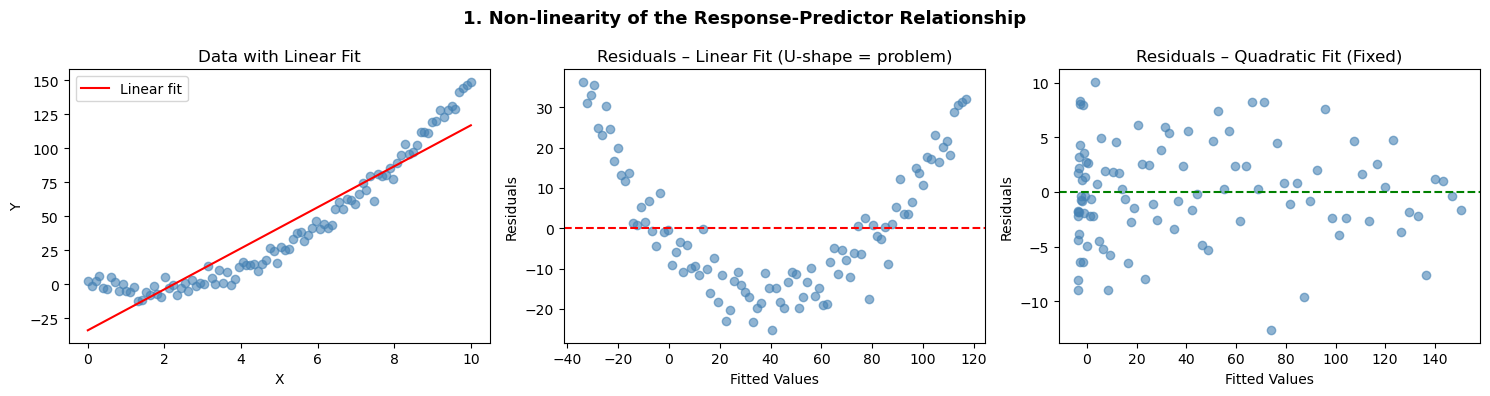

In [2]:
fig1

This plot is for Non-linearity. The first plot shows a quadratic relationship fitted by a linear model. The center plot shows a residual plot that reveals a clear U-shape, indicating non-linearity. The right plot shows how adding an X² term removes the pattern, confirming the quadratic fit is appropriate.

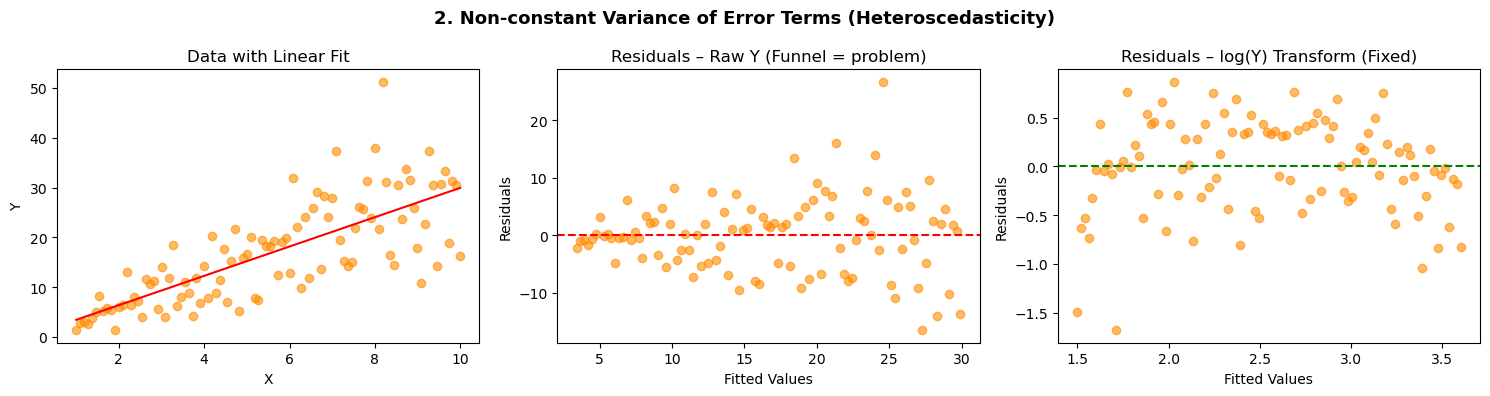

In [3]:
fig2

This plot is for Non-constant variance of error terms. The left plot shows data where the variance clearly increases with X. The plot in the center shows a residual plot with a funnel shape showing a non-constant variance of error terms. The plot on the right shows how applying a log transformation to Y stabilises the variance and removes the funnel.

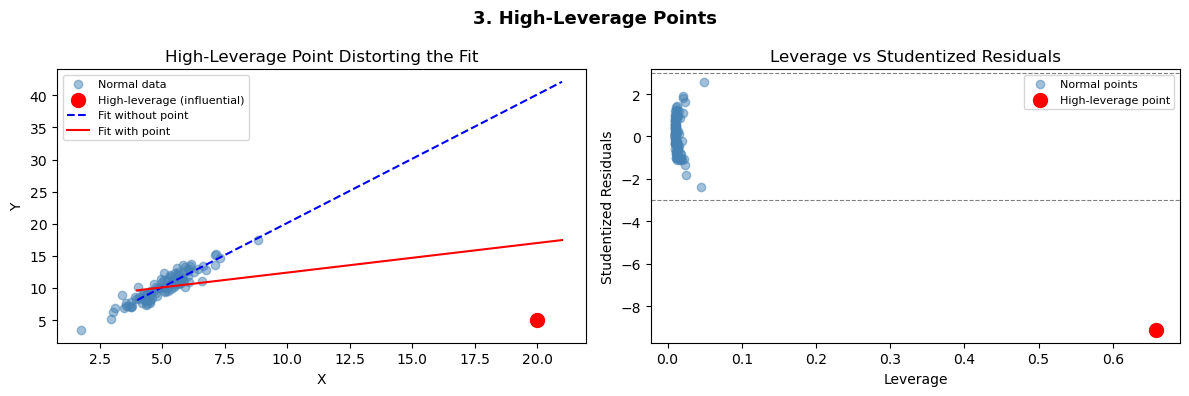

In [4]:
fig3

This plot shows High-Leverage Points. The left plot shows how a single high-leverage point can skew the regression line from the true fit. The right plot confirms the point has unusually high leverage, sitting far from all other observations.